<a href="https://colab.research.google.com/github/vlhsilvia/TRABAJOS-PRACTICOS/blob/Silviamaster/Copia_de_Geotaller2_VisualizacionDatos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Geotaller 2: Análisis y Visualización de Datos Espaciales en Python

**Objetivo del Geotaller**

1. Aprenderemos los fundamentos del análisis y visualización de datos espaciales utilizando Python y Google Colab.
2. Estaremos trabajando con datos abiertos reales para demostrar técnicas de manipulación, análisis y representación de información geoespacial con herramientas *open source*.


## Herramientas que usaremos:

- Google Colab: Para ejecutar código sin necesidad de instalación.
- GeoPandas: Para manipulación de datos espaciales.
- Folium: Para visualización de datos geoespaciales en mapas interactivos.
- Matplotlib y Seaborn: Para gráficos espaciales.

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import folium

[Podemos dar click aquí para acceder al portal de dats abiertos geográficos de Medellíon](https://www.medellin.gov.co/geomedellin/datosAbiertos?id=2216)

[Aquí podemos descargar el dataset de zonas wifi](https://www.medellin.gov.co/geomedellin/datosAbiertos/1030)

Paso 1: Cargamos los datos de las zonas Wifi

* Descargar datos desde datos abiertos de Medellín o OSM.
* Leer los datos con GeoPandas y visualizar su estructura.

In [ ]:
# Cargar el dataset de zonas WiFi en Medellín
path = '/content/shp_wifi_gratis.zip'
zonas_wifi = gpd.read_file(path)


Paso 2: Exploraramos y analizamos los datos

* Verificar sistema de coordenadas (EPSG:4326).
* Contar zonas WiFi por barrio y analizar su distribución.

In [ ]:
#Veamos las últimas filas del geodataFrame
zonas_wifi.tail()

,id_une,nombre_sit,cod_comuna,comuna,barrio,direccion,x_magnamed,y_magnamed,latitud,longitud,geometry
327,WIFIMDE0005,Casa de Gobierno San Sebastián de Palmitas,50,50,2,CL 20 # 35 – 114 (Vía Palmitas KM 2),821376.9497,1.193549e+06,6.344299,-75.691406,POINT (4702347.395 2259806.268)
328,ACP-2116276,Parque San Sebastián de Palmitas,50,50,2,"Vía Palmitas, Rural Palmitas",821343.1763,1.193549e+06,6.344299,-75.691711,POINT (4702313.62 2259806.444)
329,WIFIMDE0277,Placa Polideportiva Vereda La Aldea,50,50,2,CR 219 # 134 -26 (Vereda la Aldea Parte Baja),819985.4285,1.193327e+06,6.342285,-75.703979,POINT (4700954.699 2259590.707)
330,WIFIMDE0059,Centralidad Vereda La Suiza,50,50,2,Rural Vereda la Suiza,819924.0066,1.190984e+06,6.321106,-75.704529,POINT (4700881.698 2257248.174)
331,ACP-2126086,Parque Santa Elena,90,90,2,CL 10 A- CR 40 E,842762.0118,1.178660e+06,6.209702,-75.498188,POINT (4723658.927 2244812.403)


In [ ]:
#Hacemos uina inspección del sistema de coordenadas
zonas_wifi.crs

<Projected CRS: PROJCS["MAGNA-SIRGAS_Origen-Nacional",GEOGCS["MAGN ...>
Name: MAGNA-SIRGAS_Origen-Nacional
Axis Info [cartesian]:
- [east]: Easting (metre)
- [north]: Northing (metre)
Area of Use:
- undefined
Coordinate Operation:
- name: unnamed
- method: Transverse Mercator
Datum: Marco Geocentrico Nacional de Referencia
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

<Axes: >

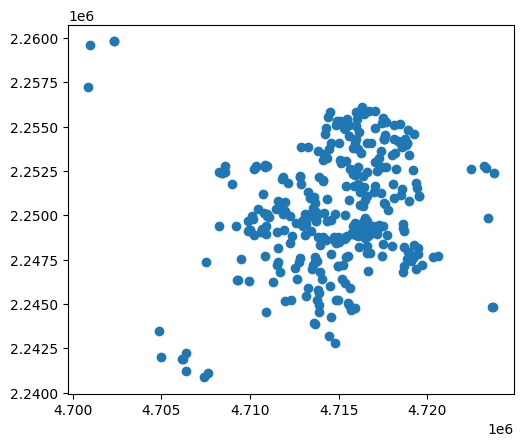

In [ ]:
#Y lo visualizamos
zonas_wifi.plot()

Paso 3: Visualizar los datos espaciales en mapas

* Podemos mejorar esta visualización estática con GeoPandas y Matplotlib

[Documentación de Geopandas](https://geopandas.org/en/stable/)

[Documentación de Matplotlib](https://matplotlib.org/)

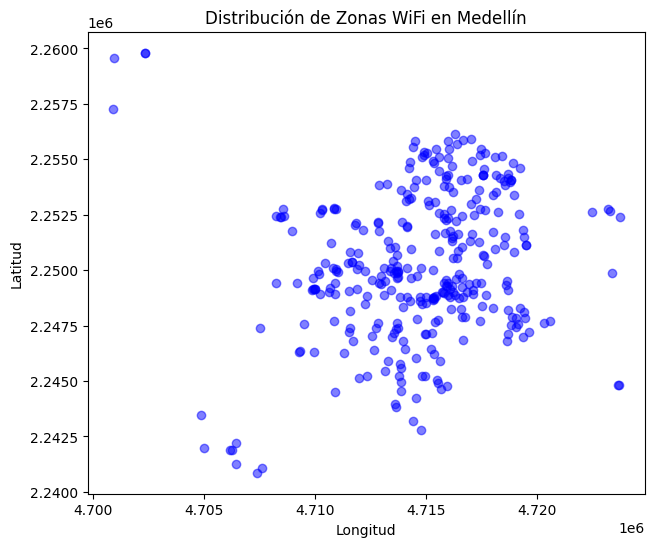

In [ ]:
# Graficar la distribución de zonas WiFi en Medellín
fig, ax = plt.subplots(figsize=(10,6))
zonas_wifi.plot(ax=ax, color='blue', alpha=0.5)
ax.set_title("Distribución de Zonas WiFi en Medellín")
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
plt.show()

Mejorémosla aún más: Agreguemos un mapa base

In [ ]:
!pip install contextily
import contextily as cx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 70.6 MB/s eta 0:00:00


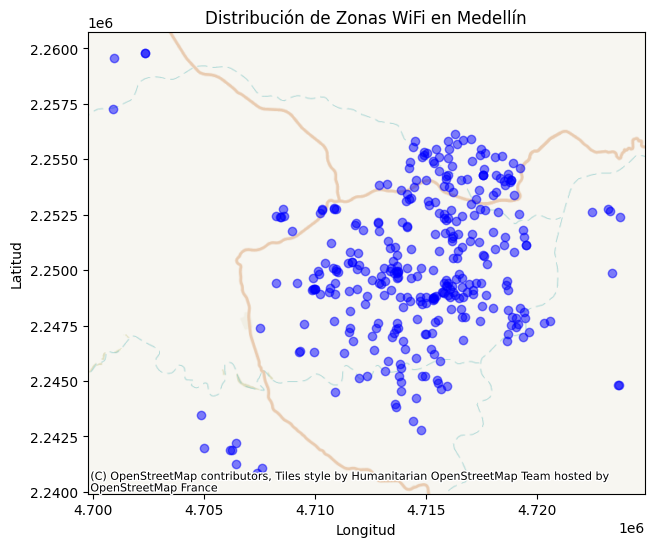

In [ ]:
# Graficar la distribución de zonas WiFi en Medellín
fig, ax = plt.subplots(figsize=(10,6))
zonas_wifi.plot(ax=ax, color='blue', alpha=0.5)
cx.add_basemap(ax=ax)
ax.set_title("Distribución de Zonas WiFi en Medellín")
ax.set_xlabel("Coordenada en X")
ax.set_ylabel("Coordenada en Y")
plt.show()

Nos aseguramos de asignarle, al *basemap*, el mismo sistema de coordenadas de referencia que el del geodataFrame

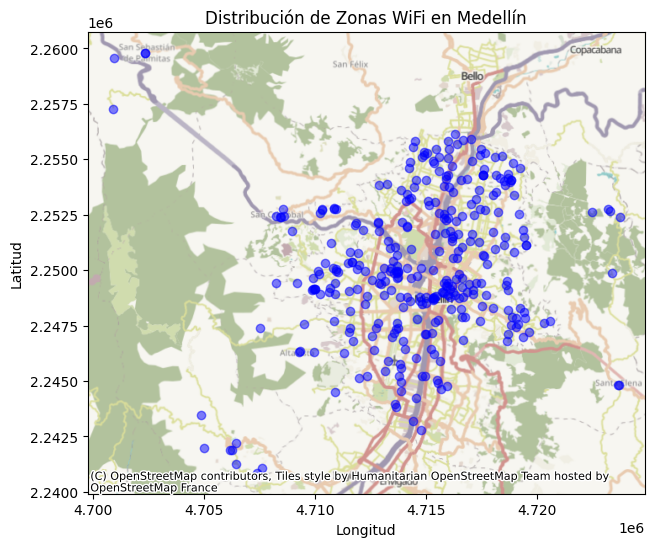

In [ ]:
# Graficar la distribución de zonas WiFi en Medellín
fig, ax = plt.subplots(figsize=(10,6))
zonas_wifi.plot(ax=ax, color='blue', alpha=0.5)
cx.add_basemap(ax=ax, crs= zonas_wifi.crs)
ax.set_title("Distribución de Zonas WiFi en Medellín")
ax.set_xlabel("Coordenada en Y")
ax.set_ylabel("Coordenada en X")
plt.show()

**Añadimos una visualización interactiva con Folium**

[Documentación de Folium](https://python-visualization.github.io/folium/latest/)

In [ ]:
import folium

# Crear un mapa centrado en Medellín
m = folium.Map(location=[6.2442, -75.5812], zoom_start=12)

m

In [ ]:
zonas_wifi.tail()

,id_une,nombre_sit,cod_comuna,comuna,barrio,direccion,x_magnamed,y_magnamed,latitud,longitud,geometry
327,WIFIMDE0005,Casa de Gobierno San Sebastián de Palmitas,50,50,2,CL 20 # 35 – 114 (Vía Palmitas KM 2),821376.9497,1.193549e+06,6.344299,-75.691406,POINT (4702347.395 2259806.268)
328,ACP-2116276,Parque San Sebastián de Palmitas,50,50,2,"Vía Palmitas, Rural Palmitas",821343.1763,1.193549e+06,6.344299,-75.691711,POINT (4702313.62 2259806.444)
329,WIFIMDE0277,Placa Polideportiva Vereda La Aldea,50,50,2,CR 219 # 134 -26 (Vereda la Aldea Parte Baja),819985.4285,1.193327e+06,6.342285,-75.703979,POINT (4700954.699 2259590.707)
330,WIFIMDE0059,Centralidad Vereda La Suiza,50,50,2,Rural Vereda la Suiza,819924.0066,1.190984e+06,6.321106,-75.704529,POINT (4700881.698 2257248.174)
331,ACP-2126086,Parque Santa Elena,90,90,2,CL 10 A- CR 40 E,842762.0118,1.178660e+06,6.209702,-75.498188,POINT (4723658.927 2244812.403)


In [ ]:
# Agregar las zonas WiFi al mapa
for idx, row in zonas_wifi.iterrows():
    folium.Marker([row.geometry.y, row.geometry.x], popup=row["barrio"]).add_to(m)

In [ ]:
m

**Por qué no podemos ver los ppuntos representados en *m*?**

1. Para poder crear visualizaciones con folium, debemos asegurarnos de que nuestro geodataFrame haya sido reproyectado al sistema de coordenadas geográficas global EPSG:4326

In [ ]:
def reproject(gdf, crs_in):
  #Crea una copia del geodataframe para no modificar el original
  gdf_copy = gdf.copy()
  #Reproyecta el geodataframe al sistema de coordenadas dado
  gdf_copy.to_crs(crs_in, inplace=True)
  return gdf_copy


In [ ]:
zonas_wifi_4326 = reproject(zonas_wifi, 4326)

In [ ]:
zonas_wifi_4326.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

Ahora sí: **volvemos a intentar agregar la información de los puntos de zonas wifi**

In [ ]:
# Agregar las zonas WiFi al mapa
for idx, row in zonas_wifi_4326.iterrows():
    folium.Marker([row.geometry.y, row.geometry.x], popup=row["barrio"]).add_to(m)

In [ ]:
m

Paso 4: Análisis Avanzado - Relación con barrios

* Unir datos de zonas WiFi con barrios de Medellín para ver cuántas hay en cada uno

[Usaremos el dataset de barrios de Medellín](https://www.medellin.gov.co/geomedellin/datosAbiertos/234)

In [ ]:
path2 = '/content/shp_barrios_y_veredas_mr.zip'
barrio = gpd.read_file(path2)

In [ ]:
barrio.tail()

,codigo,nombre,identifica,limitecomu,limitemuni,subtipo_ba,fecha_actu,Shape_Leng,Shape_Area,geometry
327,AE6,Área de Expansión Belén Rincón,7097,70,001,2,2014-12-17,4196.635540,3.327393e+05,"POLYGON ((4711330.16 2245866.385, 4711330.656 ..."
328,AUC1,Cabecera Urbana Corregimiento San Cristóbal,6000,60,001,2,2014-12-17,6870.676665,7.606237e+05,"POLYGON ((4708390.419 2252739.805, 4708390.526..."
329,7007,San José del Manzanillo,7007,70,001,2,2014-12-17,11999.322834,2.072591e+06,"POLYGON ((4711225.03 2245848.874, 4711225.553 ..."
330,1510,Guayabal,1510,15,001,1,2014-12-17,4132.420161,7.471615e+05,"POLYGON ((4714473.601 2243455.68, 4714417.29 2..."
331,9006,Santa Elena Sector Central,9006,90,001,2,2014-12-17,9165.233263,3.228433e+06,"POLYGON ((4725033.538 2244291.691, 4725001.762..."


<Axes: >

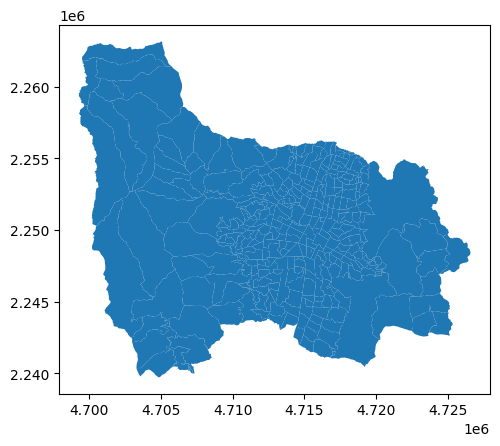

In [ ]:
barrio.plot()

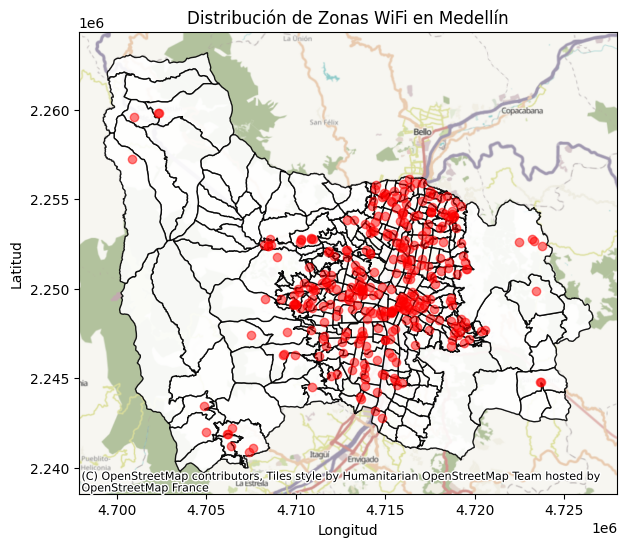

In [ ]:
fig, ax3 = plt.subplots(figsize=(10,6))
barrio.plot(ax=ax3, color='white', edgecolor='k', alpha=0.9, zorder=1)
zonas_wifi.plot(ax=ax3, color='red', alpha=0.5, zorder=2)
cx.add_basemap(ax=ax3, crs= barrio.crs)
ax3.set_title("Distribución de Zonas WiFi en Medellín")
ax3.set_xlabel("Coordenada en X")
ax3.set_ylabel("Coordenada en Y")
plt.show()


In [ ]:
# Realizar un Spatial Join entre zonas WiFi y barrios
zonas_wifi_barrio = zonas_wifi.sjoin(barrio, predicate='within', how='left')

zonas_wifi_barrio.reset_index(drop=True, inplace=True)

/usr/local/lib/python3.11/dist-packages/geopandas/geodataframe.py:2391: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: PROJCS["MAGNA-SIRGAS_Origen-Nacional",GEOGCS["MAGN ...
Right CRS: EPSG:9377

  return geopandas.sjoin(left_df=self, right_df=df, *args, **kwargs)  # noqa: B026


In [ ]:
zonas_wifi_barrio.tail()

,id_une,nombre_sit,cod_comuna,comuna,barrio,direccion,x_magnamed,y_magnamed,latitud,longitud,...,index_right,codigo,nombre,identifica,limitecomu,limitemuni,subtipo_ba,fecha_actu,Shape_Leng,Shape_Area
327,WIFIMDE0005,Casa de Gobierno San Sebastián de Palmitas,50,50,2,CL 20 # 35 – 114 (Vía Palmitas KM 2),821376.9497,1.193549e+06,6.344299,-75.691406,...,212,5004,Palmitas Sector Central,5004,50,001,2,2014-12-17,16191.527119,9.517868e+06
328,ACP-2116276,Parque San Sebastián de Palmitas,50,50,2,"Vía Palmitas, Rural Palmitas",821343.1763,1.193549e+06,6.344299,-75.691711,...,212,5004,Palmitas Sector Central,5004,50,001,2,2014-12-17,16191.527119,9.517868e+06
329,WIFIMDE0277,Placa Polideportiva Vereda La Aldea,50,50,2,CR 219 # 134 -26 (Vereda la Aldea Parte Baja),819985.4285,1.193327e+06,6.342285,-75.703979,...,311,5007,La Aldea,5007,50,001,2,2014-12-17,6192.688588,1.968150e+06
330,WIFIMDE0059,Centralidad Vereda La Suiza,50,50,2,Rural Vereda la Suiza,819924.0066,1.190984e+06,6.321106,-75.704529,...,314,5001,La Suiza,5001,50,001,2,2014-12-17,21688.878382,1.316336e+07
331,ACP-2126086,Parque Santa Elena,90,90,2,CL 10 A- CR 40 E,842762.0118,1.178660e+06,6.209702,-75.498188,...,331,9006,Santa Elena Sector Central,9006,90,001,2,2014-12-17,9165.233263,3.228433e+06


In [ ]:
zonas_wifi_barrio.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 332 entries, 0 to 331
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id_une       332 non-null    object        
 1   nombre_sit   332 non-null    object        
 2   cod_comuna   332 non-null    object        
 3   comuna       332 non-null    object        
 4   barrio       332 non-null    object        
 5   direccion    331 non-null    object        
 6   x_magnamed   332 non-null    float64       
 7   y_magnamed   332 non-null    float64       
 8   latitud      332 non-null    float64       
 9   longitud     332 non-null    float64       
 10  geometry     332 non-null    geometry      
 11  index_right  332 non-null    int64         
 12  codigo       332 non-null    object        
 13  nombre       332 non-null    object        
 14  identifica   332 non-null    object        
 15  limitecomu   332 non-null    object        
 16  

In [ ]:
#Almacenamos estas columnas en una lista cod_comuna, comuna, barrio, x_magnamed, y_magnamed, identifica,	limitecomu,	limitemuni y las eliminamos
columnas_a_eliminar = ['cod_comuna', 'comuna', 'barrio', 'x_magnamed', 'y_magnamed', 'identifica', 'limitecomu', 'limitemuni']
zonas_wifi_barrio = zonas_wifi_barrio.drop(columns=columnas_a_eliminar, errors='ignore')
zonas_wifi_barrio.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 332 entries, 0 to 331
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id_une       332 non-null    object        
 1   nombre_sit   332 non-null    object        
 2   direccion    331 non-null    object        
 3   latitud      332 non-null    float64       
 4   longitud     332 non-null    float64       
 5   geometry     332 non-null    geometry      
 6   index_right  332 non-null    int64         
 7   codigo       332 non-null    object        
 8   nombre       332 non-null    object        
 9   subtipo_ba   332 non-null    int64         
 10  fecha_actu   332 non-null    datetime64[ms]
 11  Shape_Leng   332 non-null    float64       
 12  Shape_Area   332 non-null    float64       
dtypes: datetime64[ms](1), float64(4), geometry(1), int64(2), object(5)
memory usage: 33.8+ KB


Ahora supongamos que nos interesa el siguiente dato:

1. Cuántas zonas wifi hay por barrio?
2. Cuántas zonas wifi hay en área urbana y en área rural?

Zonas wifi por barrio  

In [ ]:
# Contar cuántas zonas WiFi hay por barrio. Usa el método agg() y la función count()
zonas_por_barrio = zonas_wifi_barrio.groupby(by='nombre', as_index=False).agg({'id_une': 'count'})

zonas_por_barrio

,nombre,id_une
0,Aguas Frías,1
1,Alejandro Echavarría,3
2,Alfonso López,3
3,Altavista,2
4,Altavista Sector Central,2
...,...,...
165,Villa Nueva,3
166,Villa del Socorro,3
167,Villatina,4
168,Área de Expansión Pajarito,6


In [ ]:
#Las organizamos de forma descendente
zonas_por_barrio.sort_values(by='id_une', ascending=False, inplace=True)

In [ ]:
zonas_por_barrio

,nombre,id_une
69,La Candelaria,11
158,U.D. Atanasio Girardot,11
115,Parque Juan Pablo II,7
122,Piedras Blancas - Matasano,6
168,Área de Expansión Pajarito,6
...,...,...
59,Guayabal,1
56,Gerona,1
55,Florida Nueva,1
53,Facultad de Minas,1


In [ ]:
#Le cambiamos el nombre a 'nombre' por 'barrio/vereda' y a 'id_une' por 'número de zonas wifi'
zonas_por_barrio.rename(columns={'nombre': 'barrio/vereda', 'id_une': 'número de zonas wifi'}, inplace=True)
zonas_por_barrio

,barrio/vereda,número de zonas wifi
69,La Candelaria,11
158,U.D. Atanasio Girardot,11
115,Parque Juan Pablo II,7
122,Piedras Blancas - Matasano,6
168,Área de Expansión Pajarito,6
...,...,...
59,Guayabal,1
56,Gerona,1
55,Florida Nueva,1
53,Facultad de Minas,1


Agrupando por área urbana y área rural

In [ ]:
zonas_wifi_barrio['subtipo_ba'].unique()

array([2, 1])

Nos gustaría tener un nombre más intuitivo para cada categoría

In [ ]:
#Usa una función lambda para reemplazar, en la columna subtipo_ba, los valores de 1 por 'urbano', y 2 por 'rural'
zonas_wifi_barrio['subtipo_ba'] = zonas_wifi_barrio['subtipo_ba'].apply(lambda x: 'urbano' if x == 1 else 'rural')

In [ ]:
zonas_wifi_barrio.tail()

,id_une,nombre_sit,direccion,latitud,longitud,geometry,index_right,codigo,nombre,subtipo_ba,fecha_actu,Shape_Leng,Shape_Area
327,WIFIMDE0005,Casa de Gobierno San Sebastián de Palmitas,CL 20 # 35 – 114 (Vía Palmitas KM 2),6.344299,-75.691406,POINT (4702347.395 2259806.268),212,5004,Palmitas Sector Central,rural,2014-12-17,16191.527119,9.517868e+06
328,ACP-2116276,Parque San Sebastián de Palmitas,"Vía Palmitas, Rural Palmitas",6.344299,-75.691711,POINT (4702313.62 2259806.444),212,5004,Palmitas Sector Central,rural,2014-12-17,16191.527119,9.517868e+06
329,WIFIMDE0277,Placa Polideportiva Vereda La Aldea,CR 219 # 134 -26 (Vereda la Aldea Parte Baja),6.342285,-75.703979,POINT (4700954.699 2259590.707),311,5007,La Aldea,rural,2014-12-17,6192.688588,1.968150e+06
330,WIFIMDE0059,Centralidad Vereda La Suiza,Rural Vereda la Suiza,6.321106,-75.704529,POINT (4700881.698 2257248.174),314,5001,La Suiza,rural,2014-12-17,21688.878382,1.316336e+07
331,ACP-2126086,Parque Santa Elena,CL 10 A- CR 40 E,6.209702,-75.498188,POINT (4723658.927 2244812.403),331,9006,Santa Elena Sector Central,rural,2014-12-17,9165.233263,3.228433e+06


In [ ]:
# Contar cuántas zonas WiFi hay por barrio. Usa el método agg() y la función count()
zonas_por_suelo = zonas_wifi_barrio.groupby(by='subtipo_ba', as_index=False).agg({'id_une': 'count'})

zonas_por_suelo

,subtipo_ba,id_une
0,rural,41
1,urbano,291


In [ ]:
#Lo organizamos también de forma descendente
zonas_por_suelo.sort_values(by='id_une', ascending=False)

,subtipo_ba,id_une
1,urbano,291
0,rural,41


In [ ]:
#Cambiamos los nombres de 'subtipo_ba' a 'Clasificación de suelo' y 'id_une' por 'número de zonas wifi'
zonas_por_suelo.rename(columns={'subtipo_ba': 'Clasificación de suelo', 'id_une': 'número de zonas wifi'}, inplace=True)
zonas_por_suelo

,Clasificación de suelo,número de zonas wifi
0,rural,41
1,urbano,291


Gráficos Estadísticos

In [ ]:
#de dataFrame zonas_por_barrio selecciona los primeros 10 registros. Estos serán lso 10 con mayor número de zonas wif
zonas_por_barrio_top10 = zonas_por_barrio.head(10)
zonas_por_barrio_top10


,barrio/vereda,número de zonas wifi
69,La Candelaria,11
158,U.D. Atanasio Girardot,11
115,Parque Juan Pablo II,7
122,Piedras Blancas - Matasano,6
168,Área de Expansión Pajarito,6
35,Centro Administrativo,5
57,Girardot,5
146,Santander,5
24,Boston,5
89,Las Independencias,5


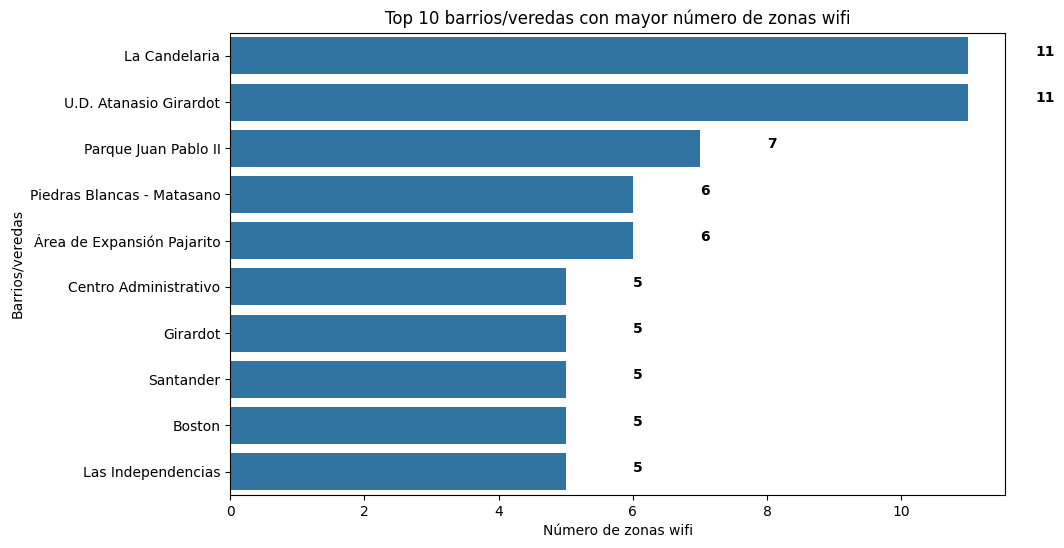

In [ ]:
#Genera, con Seaborn, un gráfico de barras horizontal con los valores de zonas_por_barrio_top10
fig, ax4 = plt.subplots(figsize=(10,6))
sns.barplot(x='número de zonas wifi', y='barrio/vereda', data=zonas_por_barrio_top10, ax=ax4)
ax4.set_title("Top 10 barrios/veredas con mayor número de zonas wifi")
ax4.set_xlabel("Número de zonas wifi")
ax4.set_ylabel("Barrios/veredas")
#Agrega annotations a las barras
for i, v in enumerate(zonas_por_barrio_top10['número de zonas wifi']):
    ax4.text(v + 1, i, str(v), color='black', fontweight='bold')
plt.show()

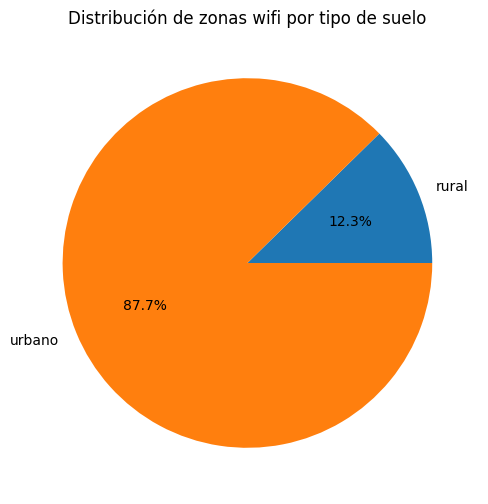

In [ ]:
# Crea un gráfico circular con los valroes de zonas_por_suelo
fig, ax5 = plt.subplots(figsize=(10,6))
ax5.pie(zonas_por_suelo['número de zonas wifi'], labels=zonas_por_suelo['Clasificación de suelo'], autopct='%1.1f%%')
ax5.set_title("Distribución de zonas wifi por tipo de suelo")
plt.show()

Ahora creamos un gráfico múltiple

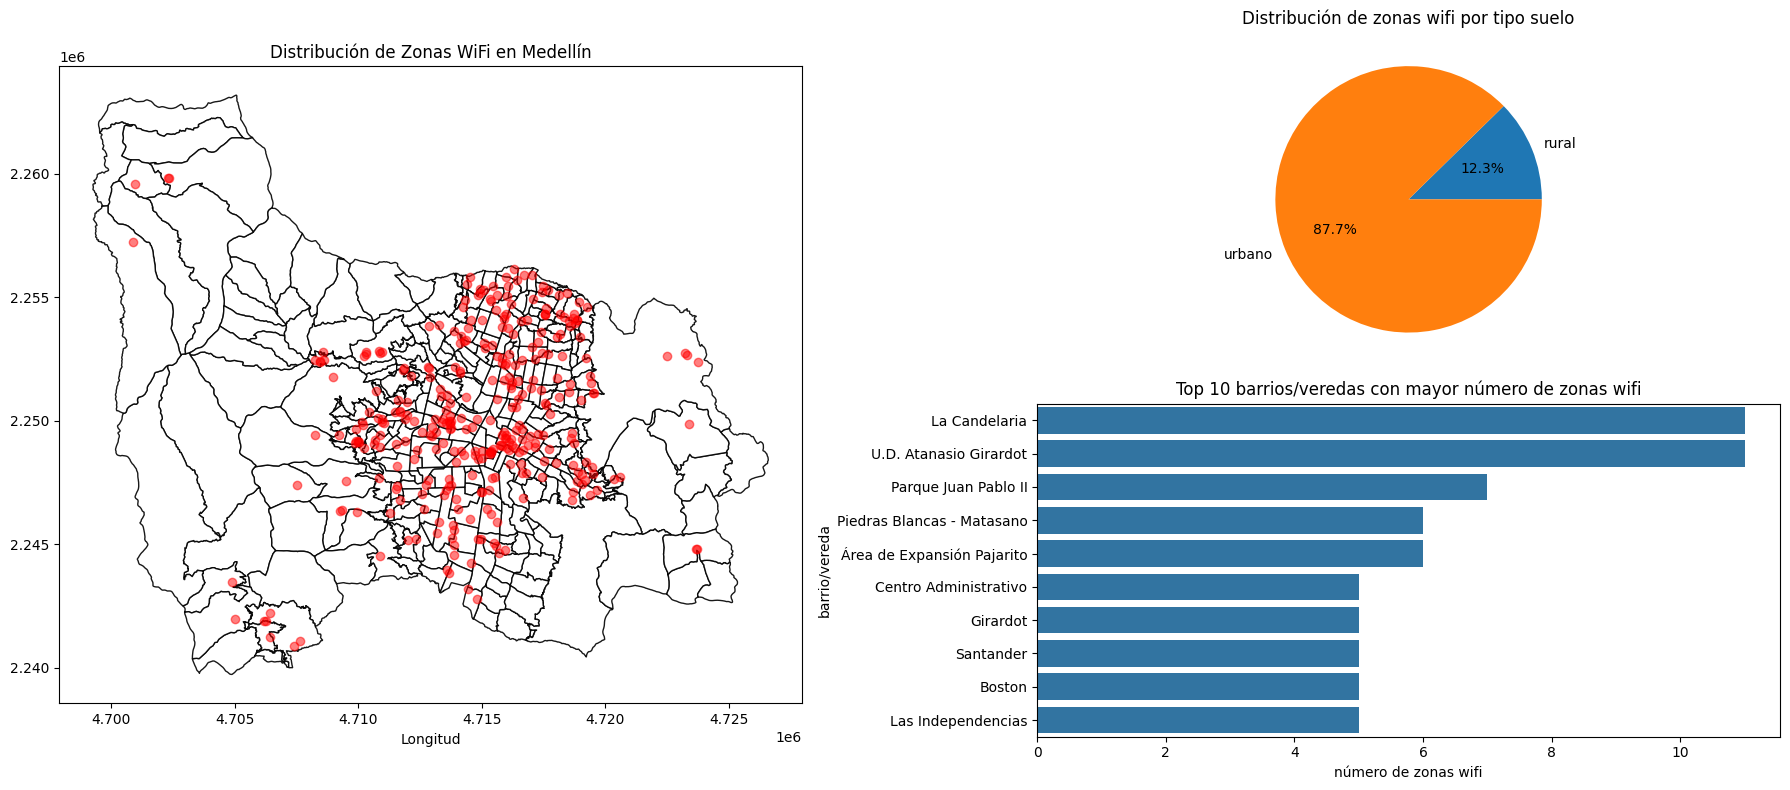

In [ ]:
fig = plt.figure(figsize=(18, 8))  # Más ancho y menos alto
gs = plt.GridSpec(2, 2, width_ratios=[1, 1], height_ratios=[1, 1])

# Mapa en mitad izquierda
ax6 = fig.add_subplot(gs[:, 0])
barrio.plot(ax=ax6, color='white', edgecolor='k', alpha=0.9, zorder=1)
zonas_wifi_barrio.plot(ax=ax6, color='red', alpha=0.5, zorder=2)
ax6.set_title("Distribución de Zonas WiFi en Medellín")
ax6.set_xlabel("Coordenada X")
ax6.set_ylabel("Coordenada Y")

# Pie chart en cuadrante superior derecho
ax7 = fig.add_subplot(gs[0, 1])
ax7.pie(zonas_por_suelo['número de zonas wifi'], labels=zonas_por_suelo['Clasificación de suelo'], autopct='%1.1f%%')
ax7.set_title("Distribución de zonas wifi por tipo suelo")

# Barplot en cuadrante inferior derecho
ax8 = fig.add_subplot(gs[1, 1])
sns.barplot(x='número de zonas wifi', y='barrio/vereda', data=zonas_por_barrio_top10, ax=ax8)
ax8.set_title("Top 10 barrios/veredas con mayor número de zonas wifi")

plt.tight_layout()

In [ ]:
#Descargamos este gráfico a nuestra máquina local
fig.savefig('grafico_multiple.png', dpi=300)